(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

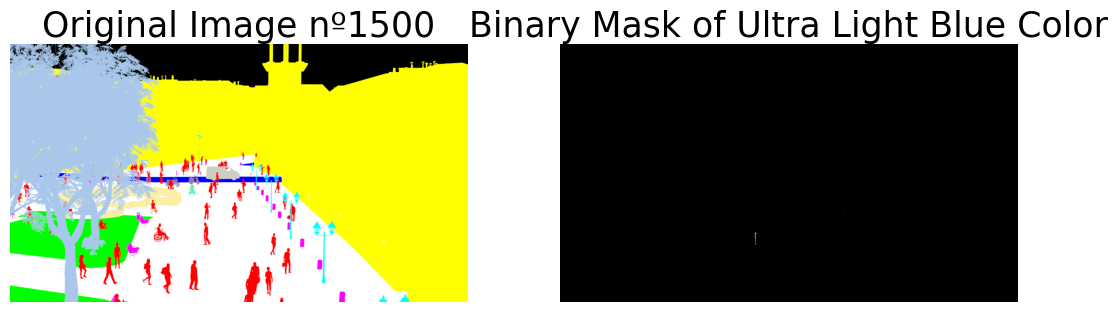

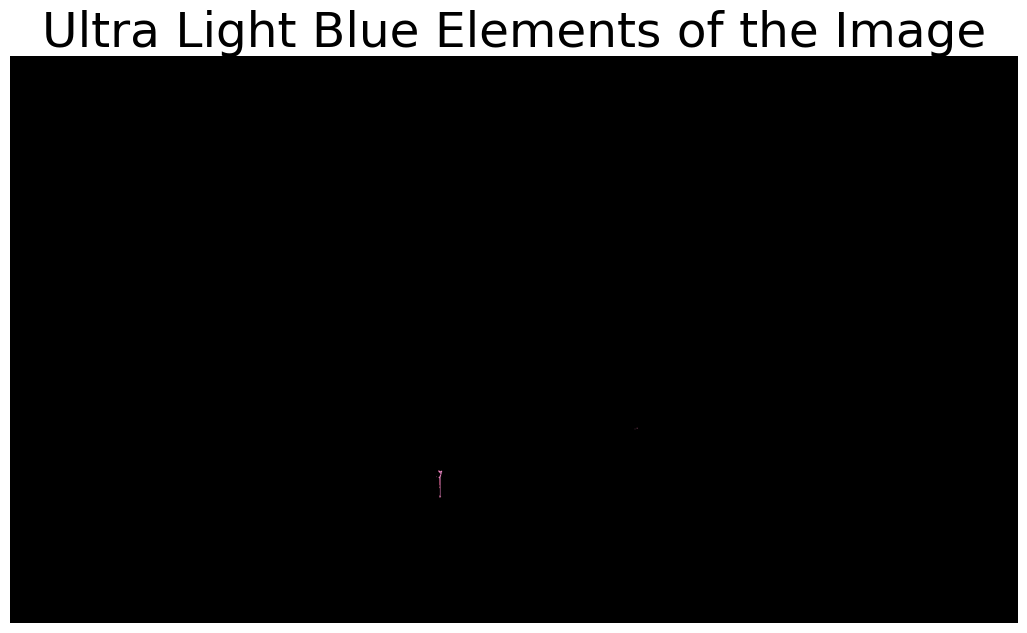

In [2]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT CRIMSON

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Define limits for Light Crimson Color >> HSV (H:158, S:97, V:247) to (H:170, S:146, V:255)
lower_bound = np.array([158, 97, 247])  # Hue, Saturation, Value
upper_bound = np.array([170, 146, 251]) # Hue, Saturation, Value

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [31]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

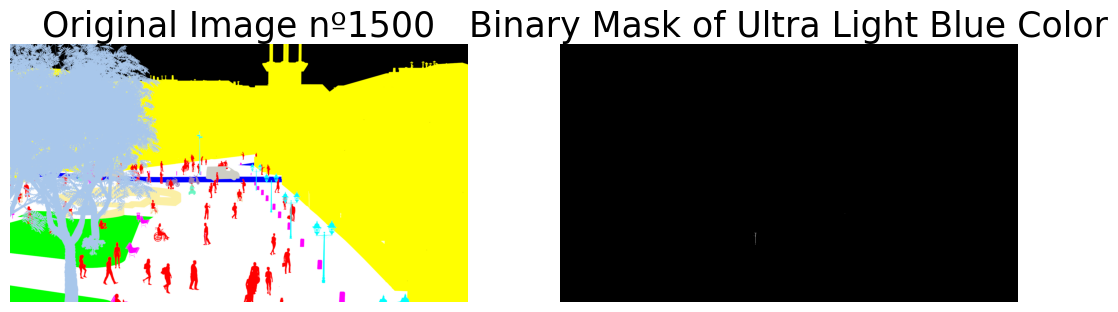

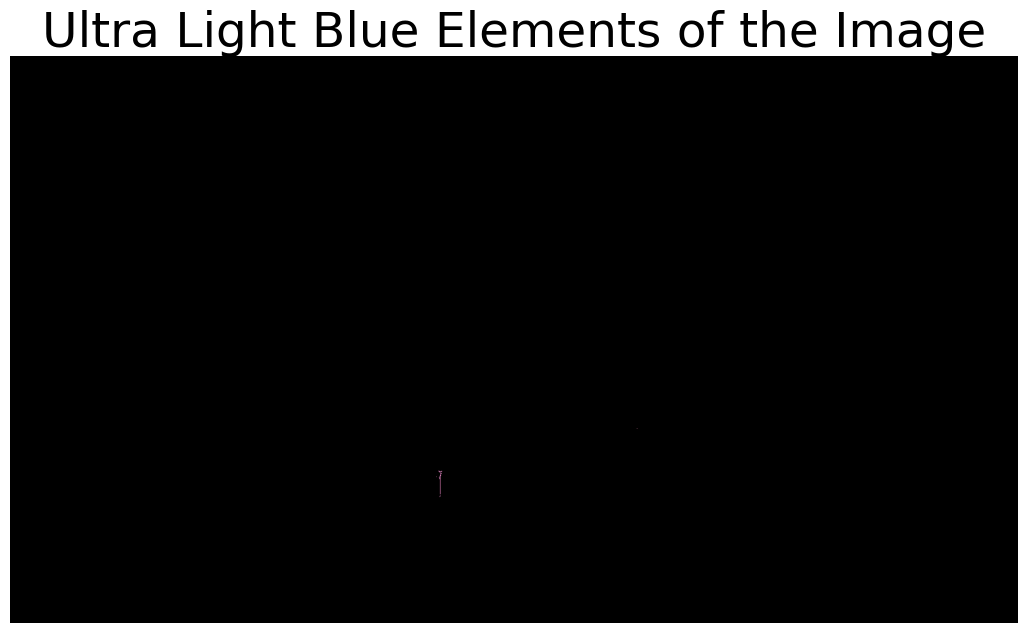

In [3]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath('/home/renato/Work/pucpr_pibic_semantic_segmentation/'))
# sys.path.append(os.path.abspath('/home/santiago/Doctorado/Entrenamientos/pucpr_pibic_semantic_segmentation-main/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT CRIMSON

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# # Define limits for Light Crimson Color >> HSV (H:158, S:97, V:247) to (H:170, S:146, V:255)
# lower_bound = np.array([158, 97, 247])  # Hue, Saturation, Value
# upper_bound = np.array([170, 146, 251]) # Hue, Saturation, Value

# # Create binary mask
# mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# Define target color in HSV (Light Crimson)
target_color = np.array([161, 108, 248])  # Hue, Saturation, Value

# Calculate Euclidean distance from the target color
distance = np.sqrt(np.sum((hsv_img - target_color) ** 2, axis=-1))

# Apply threshold to create the mask
threshold = 10  # Define acceptable distance
mask = (distance < threshold).astype(np.uint8) * 255


# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask of Ultra Light Blue Color",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Ultra Light Blue Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [29]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

TEST: 512x512 with new method and new limits

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

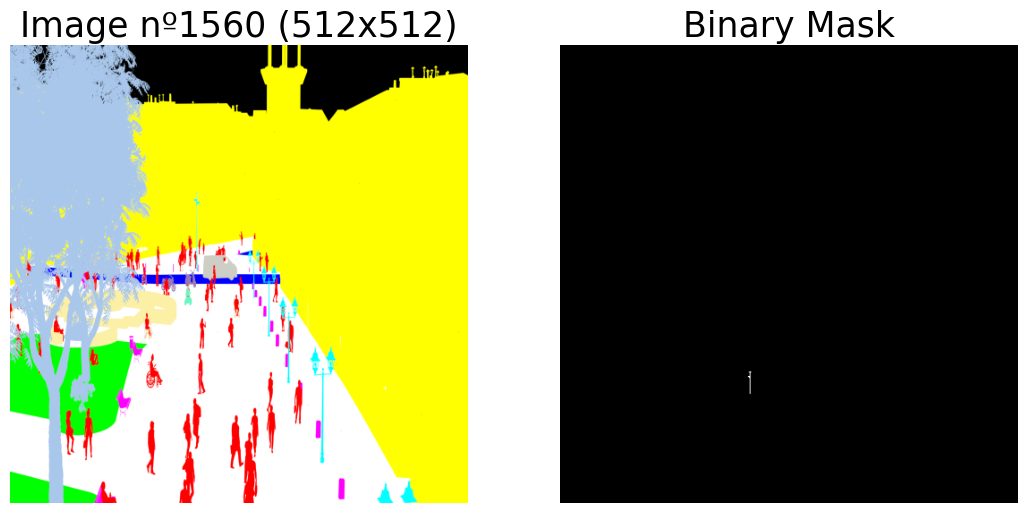

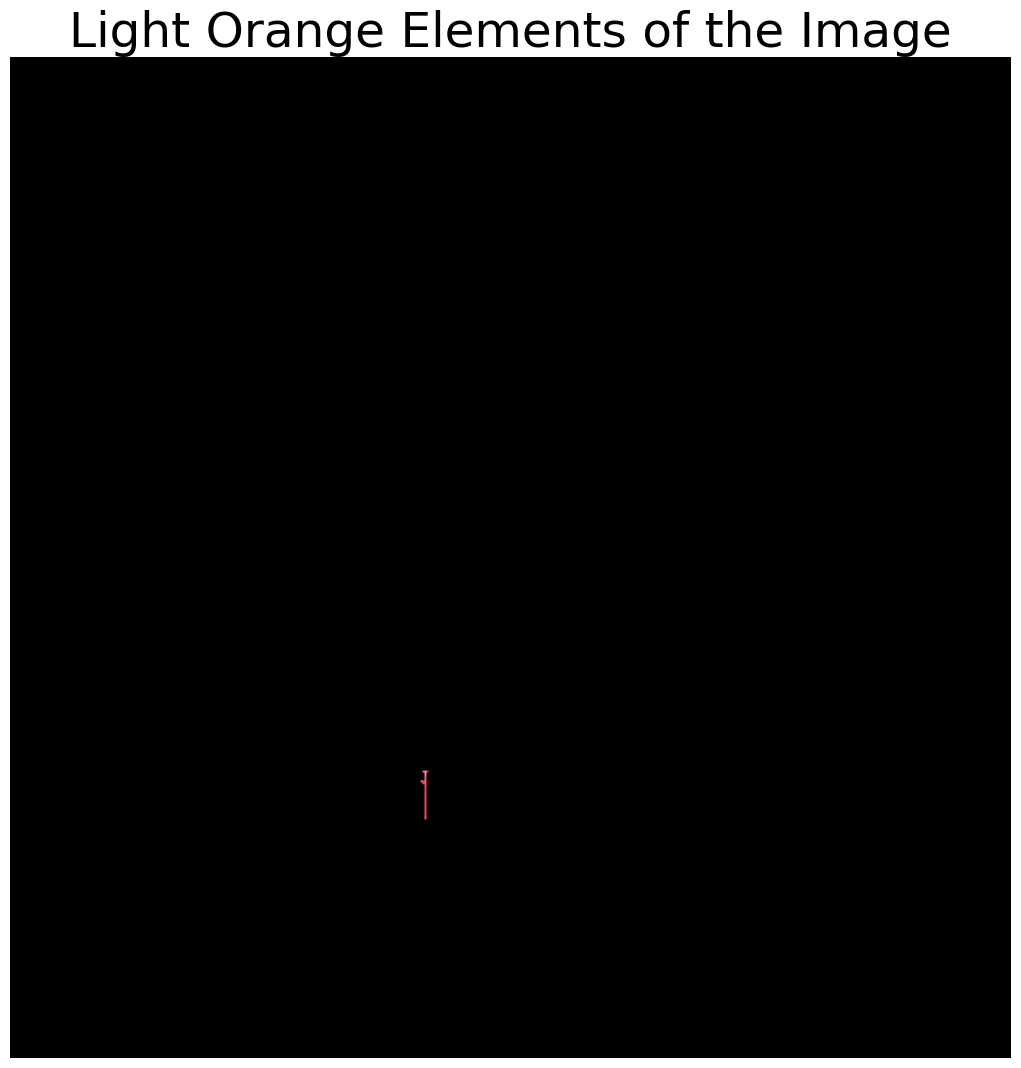

In [22]:
# Quality Test for Binary Mask (3808.npy) with img resize to 512x512
# Element close with better definition

import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
sys.path.append(os.path.abspath(r'/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
# import os


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

### Refatoração: Processo de Separação para LIGHT ORANGE ###

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)

# Resize image to 512x512
bgr_img = cv.resize(bgr_img, (512, 512), interpolation=cv.INTER_AREA) #Recommended for shrink image

# Convert to HSV for segmentation
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)

# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
# cv.imshow("Inspect Image", hsv_img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Old limits for 1920x1080
# Define limits for Light Crimson Color >> HSV (H:158, S:97, V:247) to (H:170, S:146, V:255)
# lower_bound = np.array([158, 97, 247])  # Hue, Saturation, Value
# upper_bound = np.array([170, 146, 251]) # Hue, Saturation, Value

# New limits for 512x512
# Define limits for Light Crimson Color >> HSV (H:158, S:97, V:247) to (H:170, S:146, V:255)
lower_bound = np.array([160, 54, 247])  # Hue, Saturation, Value
upper_bound = np.array([179, 205, 253]) # Hue, Saturation, Value

# Create binary mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
# Try number 1 (ok in some cases)
# Morphologic Operation (Binary Closing)
# kernel = np.ones((3,3), np.uint8)
# dilated_mask = cv.dilate(mask, kernel, iterations=1)
# erosion_mask = cv.erode(dilated_mask, kernel, iterations=1)

# Try number 2 (not good enough)
# kernel = np.ones((3,3), np.uint8)
# closing = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)
# opening = cv.morphologyEx(closing, cv.MORPH_OPEN, kernel)
# opening = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)

# Try number 3: Use contours as filter (good?)
# Solution for filter the noise
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 3 # manual fine tuning

# Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# Reassign mask with the filtered mask
mask = filtered_mask

# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Image nº{img_number} (512x512)",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
# plt.imshow(erosion_mask, cmap='gray')
# plt.imshow(opening, cmap='gray')
# plt.imshow(closing, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=erosion_mask)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=opening)
# result = cv.bitwise_and(bgr_img, bgr_img, mask=closing)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Light Orange Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')

In [ ]:
# Run the previous code block to inspect
# Inspect the Color Values for each Pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()